In [1]:
from LadrunoGraphStyle import set_default_plot_params, main_colors
set_default_plot_params()

## ShakerMaker

In [2]:
# Shakermaker
from shakermaker import shakermaker
# Crustal Model
from shakermaker.crustmodel import CrustModel
from shakermaker.pointsource import PointSource
from shakermaker.faultsource import FaultSource
# Station
from shakermaker.station import Station
from shakermaker.stationlist import StationList
# STF
from shakermaker.stf_extensions.gaussian import Gaussian

# General
import matplotlib.pylab as plt
import numpy as np

In [3]:
# Generate STF
sigma=0.06
t0=6*sigma
stf=Gaussian(t0=t0, freq=1/sigma, M0=1 ,derivative=False)

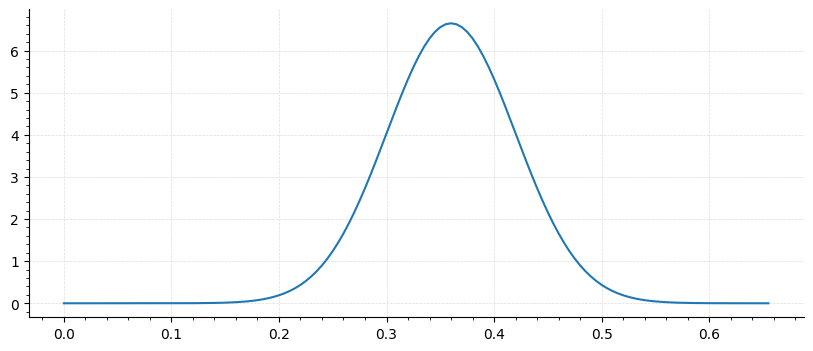

In [4]:
# Evaluate
dt=0.005
stf._dt=dt

stf._generate_data()
t_stf=stf._t 
gauss_SM = stf._data

plt.figure(figsize=(10,4))
plt.plot(t_stf, gauss_SM, label='ShakerMaker Gaussian STF')
plt.show()

In [5]:
#Initialize CrustModel
crust = CrustModel(2)

#Slow layer
vp=4.000
vs=2.000
rho=2.600
Qa=10000.
Qb=10000.
thickness = 1.0

crust.add_layer(thickness, vp, vs, rho, Qa, Qb)

#Halfspace
vp=6.000
vs=3.464
rho=2.700
Qa=10000.
Qb=10000.
thickness = 0   #Infinite thickness!
crust.add_layer(thickness, vp, vs, rho, Qa, Qb)

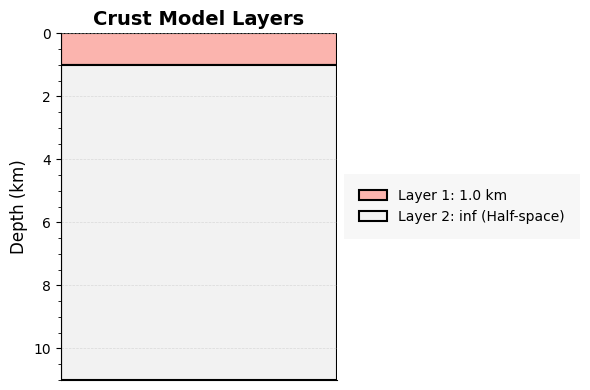

In [6]:
crust.plot()

In [7]:
M0=1e18/5e14/2
#Create source
z = 2.0                 # Source depth (km)
s,d,r = 0., 90., 0.     # Fault plane angles (deg)
source = PointSource(   [0,0,z], 
                        [s,d,r],
                        stf = Gaussian(t0=t0, freq=1/sigma, M0=M0 , derivative=False),
                    )

fault = FaultSource([source], metadata={"name":"LOH1_source"})

In [8]:
#Create recording station
x1,y1 = 8.0, 8.0           # Station location
s1 = Station([x1,y1,0.0], metadata={"name":"sta01", "save_gf": True,
                                    })

x2,y2 = 6.0, 8.0           # Station location
s2 = Station([x2,y2,0.0], metadata={"name":"sta02",  "save_gf": True,
                                    })

stations = StationList([s1, s2], {})

In [9]:
#Create model
model = shakermaker.ShakerMaker(crust, fault, stations)
model.run(
 dt=0.005,          # Output time-step
 nfft=2048*2,       # N timesteps
 tb=20,             # Initial zero-padding
 smth=1, 
 dk=0.05/2,         # wavenumber discretization
 verbose=True,
 )



ShakerMaker LADRUNO_numpy2 Run begin. dt=0.005 nfft=4096 dk=0.025 tb=20 tmin=0.0 tmax=100
-----------------------------------------------------------------------------------------
rank=0 nprocs=1 ipair=0 skip_pairs=1 npairs=2 !!
calling core START
_call_core
        psource.x = [0. 0. 2.]
        station.x = [8.0, 8.0, 0.0]
ShakerMaker._call_core - calling core.subgreen
	mb: 3
	src: 3
	rcv: 1
	styoe: 2
	updn: 0
	d: [1. 1. 0.]
	a: [4. 6. 6.]
	b: [2.    3.464 3.464]
	rho: [2.6 2.7 2.7]
	qa: [10000. 10000. 10000.]
	qb: [10000. 10000. 10000.]
	dt: 0.005
	nfft: 4096
	tb: 20
	nx: 1
	sigma: 2
	smth: 1
	wc1: 1
	wc2: 2
	pmin: 0
	pmax: 1
	dk: 0.025
	kc: 15.0
	taper: 0.9
	x: 11.313708498984761
	pf: 0.0
	df: 1.5707963267948966
	lf: 0.0
	sx: 0.0
	sy: 0.0
	rx: 8.0
	ry: 8.0
	
calling core END
0 of 2 done  ETA=0:00:01.8  t=[1.7930, 42.7480] (tmin=0.0000 tmax=100.0000)
rank=0 nprocs=1 ipair=1 skip_pairs=1 npairs=2 !!
calling core START
_call_core
        psource.x = [0. 0. 2.]
        station.x = [6.

In [10]:
z_v1,e_v1,n_v1,t1 = s1.get_response()
z_v2,e_v2,n_v2,t2 = s2.get_response()

### S1 station x=8, y=8 , z=0

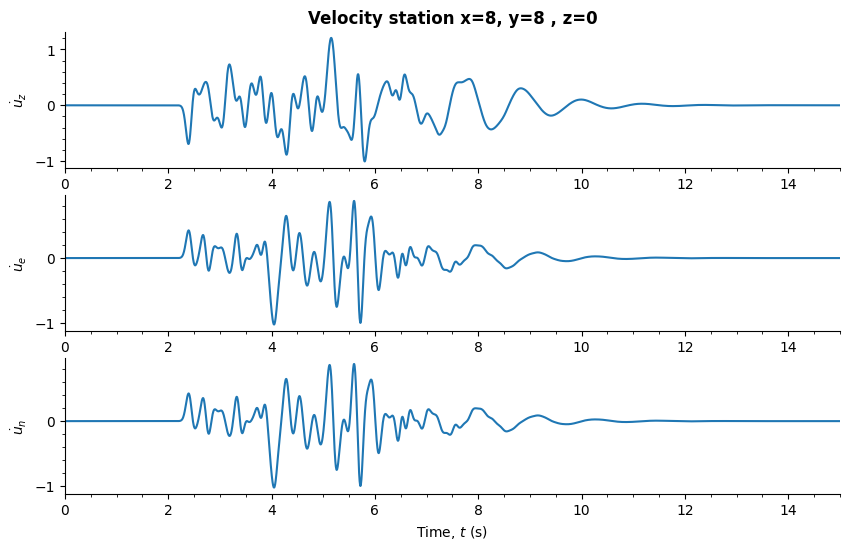

In [11]:
plt.figure(figsize=(10,6))
plt.subplot(3,1,1)
plt.title("Velocity station x=8, y=8 , z=0", fontweight='bold')
plt.plot(t1, z_v1, label="Z (Shakermaker)")
plt.xlabel("Time [s]")
plt.ylabel(r"$\dot{u}_z$")
plt.xlim([0,15])
plt.grid()

plt.subplot(3,1,2)
plt.plot(t1, e_v1, label="E (Shakermaker)")
plt.ylabel(r"$\dot{u}_e$")
plt.xlim([0,15])
plt.grid()

plt.subplot(3,1,3)
plt.plot(t1, n_v1, label="N (Shakermaker)")
plt.ylabel(r"$\dot{u}_n$")
plt.xlabel(r"Time, $t$ (s)")
plt.xlim([0,15])
plt.grid()

plt.show()

### S2 station x=6, y=8 , z=0

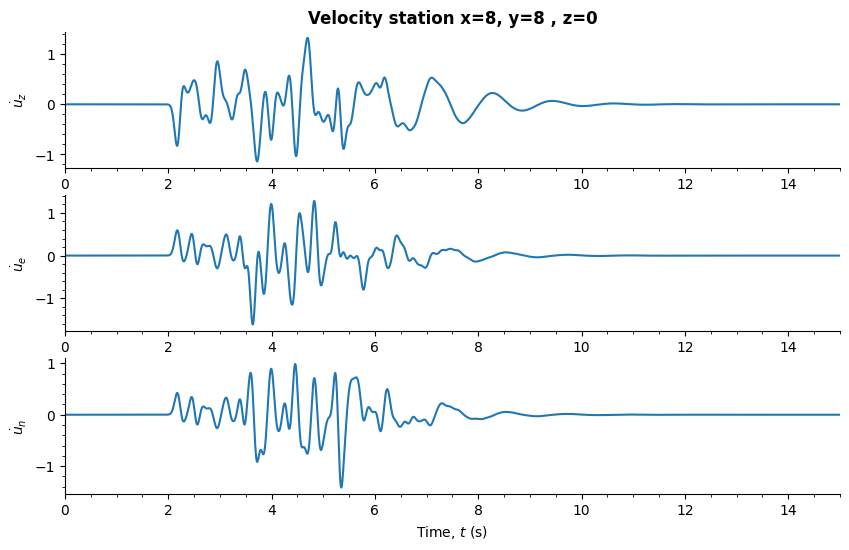

In [12]:
plt.figure(figsize=(10,6))
plt.subplot(3,1,1)
plt.title("Velocity station x=8, y=8 , z=0", fontweight='bold')
plt.plot(t2, z_v2, label="Z (Shakermaker)")
plt.xlabel("Time [s]")
plt.ylabel(r"$\dot{u}_z$")
plt.xlim([0,15])
plt.grid()

plt.subplot(3,1,2)
plt.plot(t2, e_v2, label="E (Shakermaker)")
plt.ylabel(r"$\dot{u}_e$")
plt.xlim([0,15])
plt.grid()

plt.subplot(3,1,3)
plt.plot(t2, n_v2, label="N (Shakermaker)")
plt.ylabel(r"$\dot{u}_n$")
plt.xlabel(r"Time, $t$ (s)")
plt.xlim([0,15])
plt.grid()

plt.show()

## Green Functions

In [13]:
gf_s1 = s1.get_greens_functions()
gf_s2 = s2.get_greens_functions()

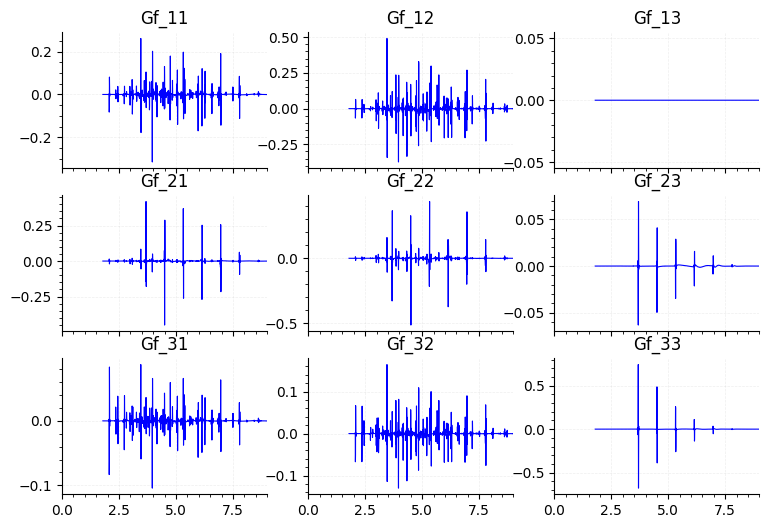

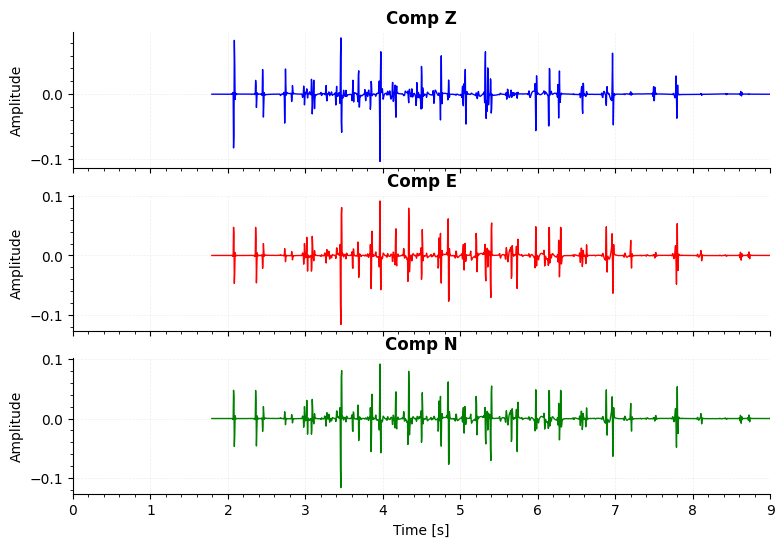

In [14]:
z, e, n, t, tdata, t0 = gf_s1[0]
# tdata shape: (1, 9, nt)
nt = tdata.shape[2]
t_gf = np.arange(nt) * (t[1] - t[0]) + t0

labels = [
    ['Gf_11', 'Gf_12', 'Gf_13'],
    ['Gf_21', 'Gf_22', 'Gf_23'],
    ['Gf_31', 'Gf_32', 'Gf_33'],
]

# Tensor GF
fig, axes = plt.subplots(3, 3, figsize=(9, 6), sharex=True)
for i in range(3):
    for j in range(3):
        axes[i, j].plot(t_gf, tdata[0, i*3 + j, :], 'b-', linewidth=0.8)
        axes[i, j].set_title(labels[i][j])
        axes[i, j].grid(True, alpha=0.3)
        axes[i, j].set_xlim([0, 9])
plt.show()

# Comp Z, E, N 
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, data, label, color in zip(axes, [z, e, n], ['Z', 'E', 'N'], ['b', 'r', 'g']):
    ax.plot(t, data, color=color, linewidth=1)
    ax.set_title(f'Comp {label}', fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.set_xlim([0, 9])
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time [s]')
plt.show()

## Convolve response

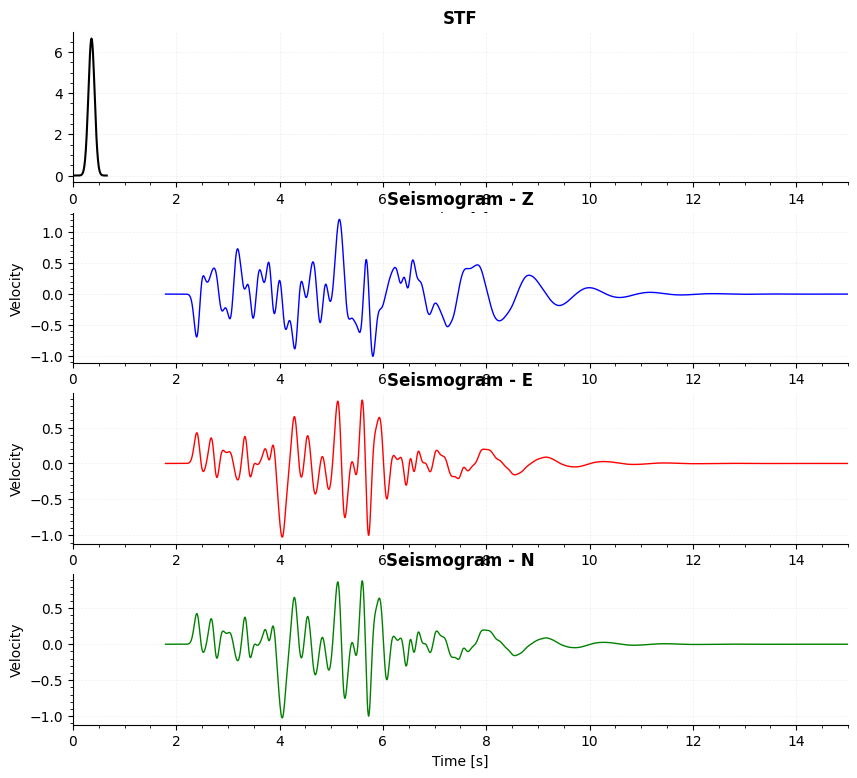

In [15]:
z, e, n, t, tdata, t0 = gf_s1[0]

# Convolve — igual que run()
stf.dt = dt
z_stf = stf.convolve(z, t)*M0
e_stf = stf.convolve(e, t)*M0
n_stf = stf.convolve(n, t)*M0

fig, axes = plt.subplots(4, 1, figsize=(10, 9))
axes[0].plot(t_stf, gauss_SM, 'k-', linewidth=1.5)
axes[0].set_title('STF', fontweight='bold')
axes[0].set_xlabel('Time [s]')
axes[0].set_xlim([0, 15])
axes[0].grid(True, alpha=0.3)

for ax, data, label, color in zip(axes[1:], [z_stf, e_stf, n_stf], ['Z', 'E', 'N'], ['b', 'r', 'g']):
    ax.plot(t, data, color=color, linewidth=1)
    ax.set_title(f'Seismogram - {label}', fontweight='bold')
    ax.set_ylabel('Velocity')
    ax.set_xlim([0, 15])
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time [s]')
plt.show()